[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


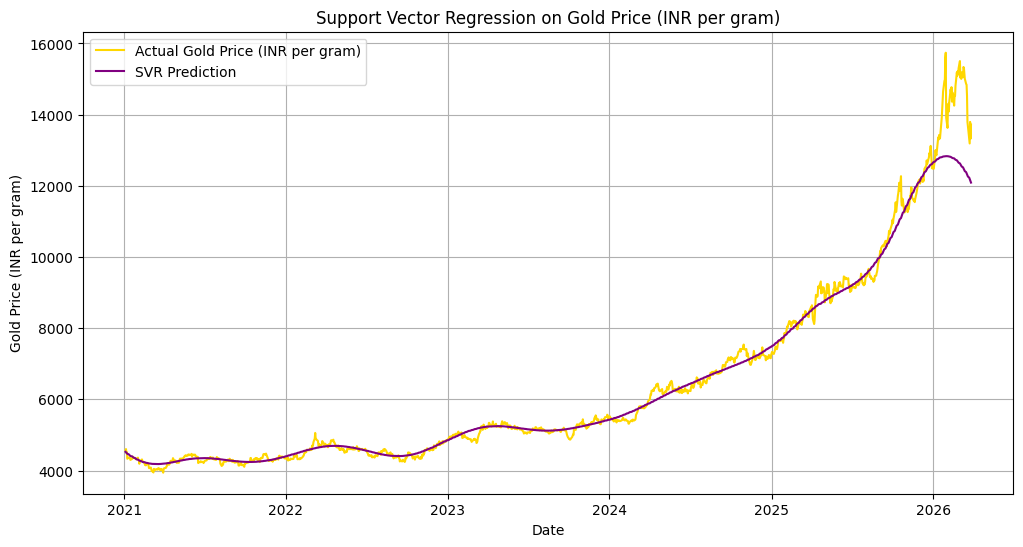

Next Day (2026-03-28) Predicted Gold Price (INR per gram): 12052.53


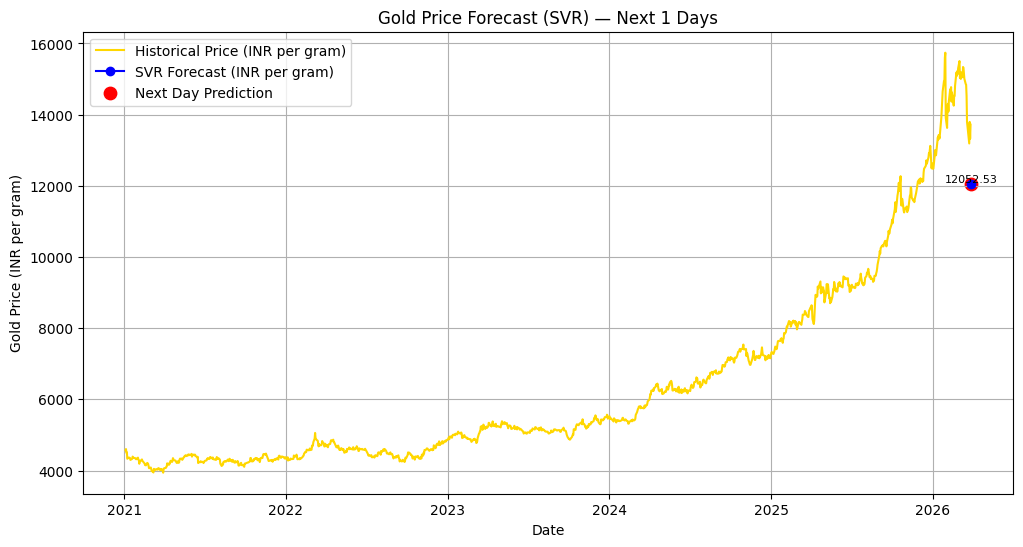

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
import yfinance as yf


gold = yf.download("GC=F", start="2021-01-01")
fx = yf.download("USDINR=X", start="2021-01-01")
gold.columns = gold.columns.get_level_values(0)
fx.columns = fx.columns.get_level_values(0)
gold = gold[['Close']].rename(columns={'Close': 'Gold_USD'}).dropna()
fx = fx[['Close']].rename(columns={'Close': 'USDINR'}).dropna()
df = gold.join(fx, how='inner')
df['Gold_INR'] = df['Gold_USD'] * df['USDINR']
df['Gold_INR_per_gram'] = df['Gold_INR'] / 31.1034768
df['t'] = np.arange(len(df))

X = df[['t']]
y = df['Gold_INR_per_gram']


# Support Vector Regression (SVR)

svr = SVR(kernel='rbf', C=100, gamma=0.0001, epsilon=0.1)
svr.fit(X, y)

df['SVR_Predicted'] = svr.predict(X)

# Plot actual vs predicted
plt.figure(figsize=(12,6))
plt.plot(df.index, df['Gold_INR_per_gram'], label="Actual Gold Price (INR per gram)", color="gold")
plt.plot(df.index, df['SVR_Predicted'], label="SVR Prediction", color="purple")

plt.title("Support Vector Regression on Gold Price (INR per gram)")
plt.xlabel("Date")
plt.ylabel("Gold Price (INR per gram)")
plt.legend()
plt.grid(True)
plt.show()

#----------------------------------------------
future_days = 1
future_t = pd.DataFrame({'t': np.arange(len(df), len(df) + future_days)})
future_pred = svr.predict(future_t)
future_dates = pd.date_range(start=df.index[-1] + pd.Timedelta(days=1), periods=future_days, freq='D')

next_date = future_dates[0]
next_price = future_pred[0]

print(f"Next Day ({next_date.date()}) Predicted Gold Price (INR per gram): {next_price:.2f}")

plt.figure(figsize=(12,6))

# Historical data
plt.plot(df.index, df['Gold_INR_per_gram'], 
         label="Historical Price (INR per gram)", color="gold")

# Future prediction line with markers
plt.plot(future_dates, future_pred,label="SVR Forecast (INR per gram)", color="blue", marker='o')

for date, price in zip(future_dates, future_pred):
    plt.text(date, price, f"{price:.2f}", fontsize=8, ha='center', va='bottom')
    
plt.scatter(next_date, next_price, color="red", s=80, label="Next Day Prediction")

plt.title(f"Gold Price Forecast (SVR) — Next {future_days} Days")
plt.xlabel("Date")
plt.ylabel("Gold Price (INR per gram)")
plt.legend()
plt.grid(True)
plt.show()